## Simple Linear regression 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt  
import numpy as np  

%matplotlib inline 


In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Weight')

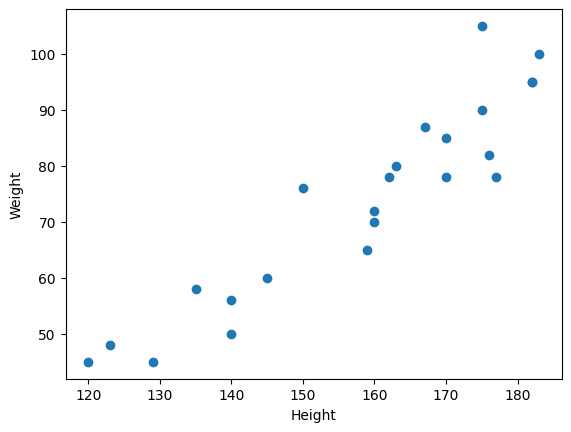

In [3]:
## scatter  
plt.scatter(df['Height'] , df['Weight'])
plt.xlabel("Height")
plt.ylabel("Weight")

In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


wight and height are heighly correlated  as corellation is 0.931142

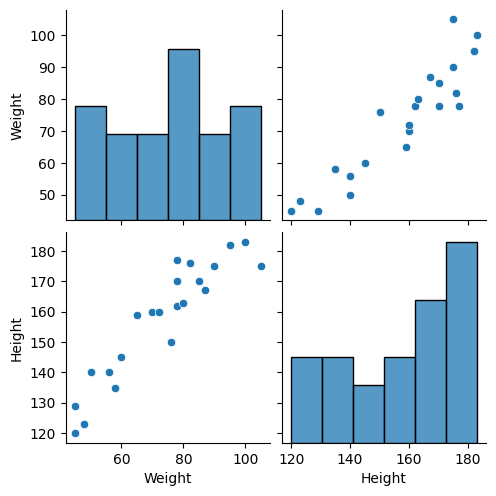

In [5]:
### Seaborn
import seaborn as  sns
sns.pairplot(df)

In [6]:
## independent and dependent features 

x=df[['Weight']]
type(x)
np.array(x).shape

(23, 1)

In [7]:
y=df['Height']

In [8]:
## Train test Split 
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test  = train_test_split(x , y ,test_size=0.25 ,random_state=42)

# test size 0.25 = 25%  


In [9]:
x_train

,Weight
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50


In [10]:
## Standardization  

from sklearn.preprocessing import StandardScaler 


In [11]:
scalar=StandardScaler()
x_train = scalar.fit_transform(x_train)

In [12]:
# i wnat only mean and standard deviation of the train data set 
# then use that in test data set 



x_test=scalar.transform(x_test)
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [13]:
### Apply Simple linear regression ml algo  
from sklearn.linear_model import  LinearRegression
regression = LinearRegression(n_jobs=-1)



In [14]:
regression.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [15]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [16]:
regression.coef_
## y^ = b0 + b1 xi 


array([17.2982057])

In [17]:
print("Coefficient or slope  is : " ,regression.coef_)
print("Intercept  :" , regression.intercept_)

Coefficient or slope  is :  [17.2982057]
Intercept  : 156.47058823529412


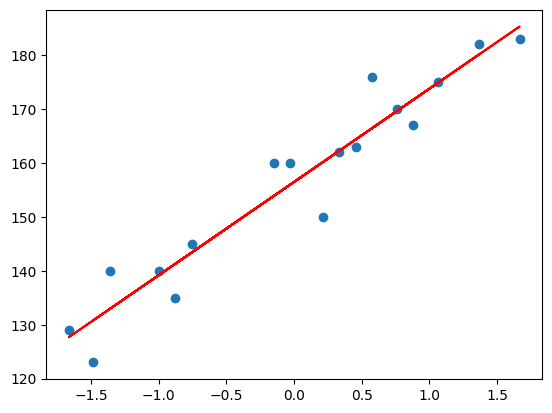

In [18]:
## plot trainning data plot best fit line 

plt.scatter(x_train , y_train)
plt.plot(x_train , regression.predict(x_train),'red')


In [19]:
### prediction for the test data  

y_pred=regression.predict(x_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse=mean_squared_error(y_test , y_pred)
mae=mean_absolute_error(y_test , y_pred)
rmse=np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## r Square 

r^2 = 1- ssr(sum of square of residues)/sst(total sum of squares)
 

In [21]:
from sklearn.metrics import r2_score
score = r2_score(y_test  , y_pred)
print (score)

0.7360826717981276


In [23]:
## OLS LInear regression 

import statsmodels.api as sm 
model=sm.OLS(y_train , x_train).fit()

In [24]:
prediction=model.predict(x_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [25]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Wed, 12 Aug 2026   Prob (F-statistic):                       0.664
Time:                        00:46:12   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\saura\OneDrive\Desktop\VS CODE FILES\python ml\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
